In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

## Carregar Dataset

In [9]:
df = pd.read_csv("titanic-dataset.csv")

df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]

## Pré-processamento

In [10]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())


X = df.drop("Survived", axis=1)
y = df["Survived"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Treinamento K-means

In [11]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

## Mapeamento de Clusters

In [12]:
mapping = {}

for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    most_common_class = y[mask].mode()[0]
    mapping[cluster_id] = most_common_class

y_pred = np.array([mapping[c] for c in clusters])

## Avaliação

In [13]:
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("Accuracy:", round(acc, 4))
print("\nConfusion Matrix:\n", cm)
print("\nAdjusted Rand Index (ARI):", round(ari, 4))
print("Normalized Mutual Information (NMI):", round(nmi, 4))

Accuracy: 0.6745

Confusion Matrix:
 [[450  99]
 [191 151]]

Adjusted Rand Index (ARI): 0.1118
Normalized Mutual Information (NMI): 0.0624


## Visualização

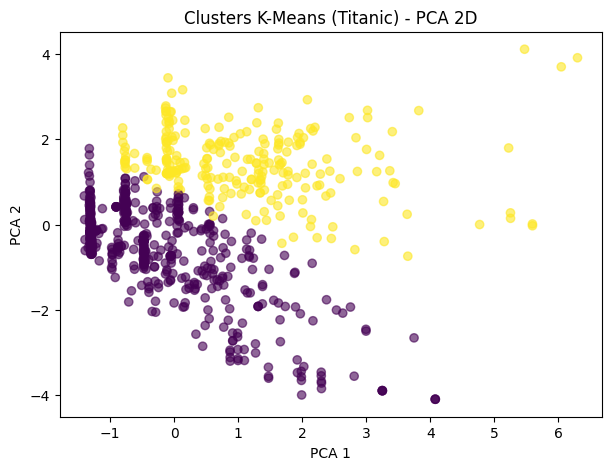

In [14]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, alpha=0.6)
plt.title("Clusters K-Means (Titanic) - PCA 2D")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()